In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix


In [49]:
df = pd.read_csv("../data/star-galaxy-quasar.csv", comment="#")

# Feature Engineering: Color Indices
df["u_g"] = df["u"] - df["g"]
df["g_r"] = df["g"] - df["r"]
df["r_i"] = df["r"] - df["i"]
df["i_z"] = df["i"] - df["z"]

# Data Cleaning: Remove missing value placeholders (-9999)
df = df[(df[["u", "g", "r", "i", "z"]] > -1000).all(axis=1)]

# Prepare features and labels
X = df.drop(columns=["objid", "class"])
y_true = df["class"]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for Dimensionality Reduction (6 components capture ~95% variance)
pca_95 = PCA(n_components=6, random_state=42)
X_pca95 = pca_95.fit_transform(X_scaled)

print(f"Original shape: {X.shape}")
print(f"PCA shape: {X_pca95.shape}")

FileNotFoundError: [Errno 2] No such file or directory: '../data/star-galaxy-quasar.csv'

## K-Means Clustering

In [ ]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca95)
    
    inertia.append(kmeans.inertia_)

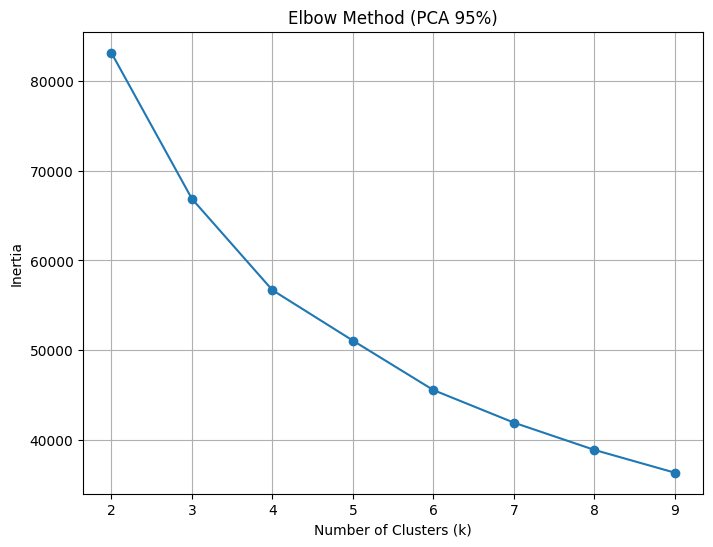

In [ ]:
## Elbow PLot
plt.figure(figsize=(8, 6))
plt.grid()
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (PCA 95%)")
plt.show()

In [ ]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters_pca95 = kmeans.fit_predict(X_pca95)

## Evaluation

In [ ]:
ari = adjusted_rand_score(y_true, clusters_pca95)
nmi = normalized_mutual_info_score(y_true, clusters_pca95)

print(f"ARI (PCA95): {ari:.4f}")
print(f"NMI (PCA95): {nmi:.4f}")

ARI (PCA95): 0.3728
NMI (PCA95): 0.2828


In [ ]:
crosstab = pd.crosstab(y_true, clusters_pca95)
print(crosstab)

col_0     0     1     2
class                  
GALAXY  150  1035  7250
QSO     605    13    67
STAR    200   150   515


In [ ]:
from sklearn.metrics import confusion_matrix
label_map = {0: "QSO", 1: "STAR", 2: "GALAXY"}

clusters_str = [label_map[x] for x in clusters_pca95]
cm = confusion_matrix(y_true, clusters_str)
cm_prop = cm.astype('float') / cm.sum(axis=1, keepdims=True)


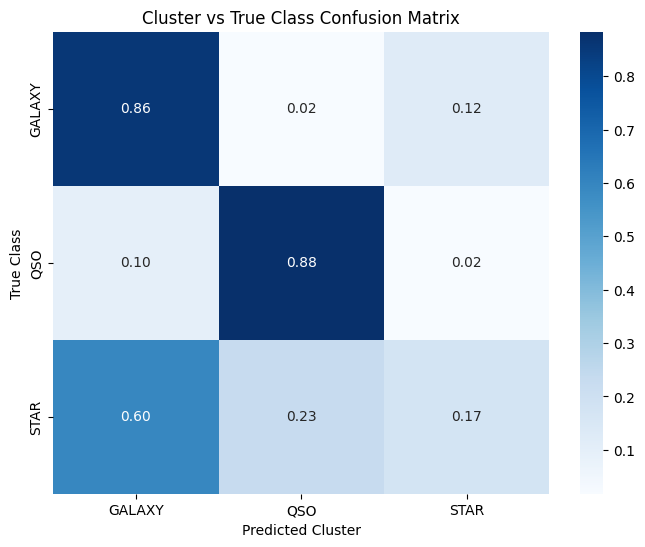

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_prop,
    annot=True,
    fmt='.2f',
    cmap="Blues",
    yticklabels=["GALAXY", "QSO", "STAR"],
    xticklabels=["GALAXY", "QSO", "STAR"],
)

plt.xlabel("Predicted Cluster")
plt.ylabel("True Class")
plt.title("Cluster vs True Class Confusion Matrix")
plt.show()


## Visualization in PCA Space

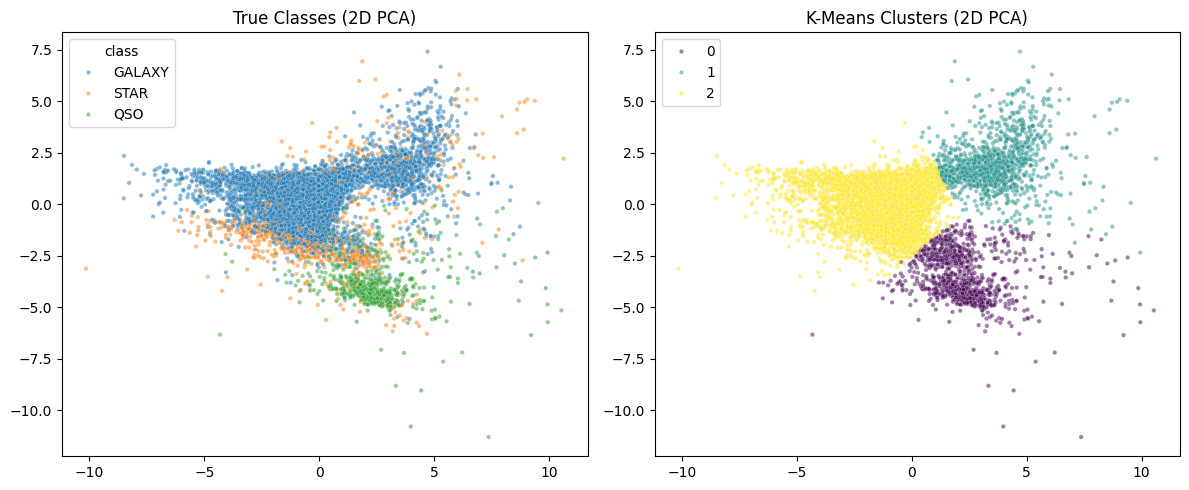

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca95[:, 0], y=X_pca95[:, 1], hue=y_true, alpha=0.5, s=10)
plt.title("True Classes (2D PCA)")

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca95[:, 0], y=X_pca95[:, 1], hue=clusters_pca95, alpha=0.5, s=10, palette="viridis")
plt.title("K-Means Clusters (2D PCA)")

plt.tight_layout()
plt.show()

In [ ]:
import joblib
joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']